In [1]:
# 1. Import Libraries
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [2]:
# 2. Load Dataset
# -----------------------------
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# 3. Preprocessing (Padding)
# -----------------------------
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [4]:
# 4. Build LSTM Model
# -----------------------------
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# LSTM Layer (basic)
model.add(LSTM(64))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 5. Compile Model
# -----------------------------
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [6]:
# 6. Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 284ms/step - accuracy: 0.7803 - loss: 0.4520 - val_accuracy: 0.8482 - val_loss: 0.3468
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 272ms/step - accuracy: 0.8937 - loss: 0.2710 - val_accuracy: 0.8700 - val_loss: 0.3195
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 283ms/step - accuracy: 0.9258 - loss: 0.1950 - val_accuracy: 0.8616 - val_loss: 0.3375
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 139s 273ms/step - accuracy: 0.9500 - loss: 0.1397 - val_accuracy: 0.8578 - val_loss: 0.3602
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 145s 283ms/step - accuracy: 0.9574 - loss: 0.1152 - val_accuracy: 0.8408 - val_loss: 0.4595


In [7]:
# 7. Evaluate Model
# -----------------------------
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.8468 - loss: 0.4502

Test Accuracy: 0.8468400239944458


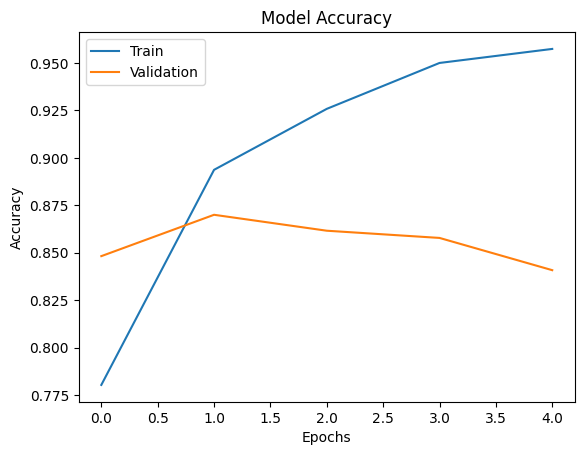

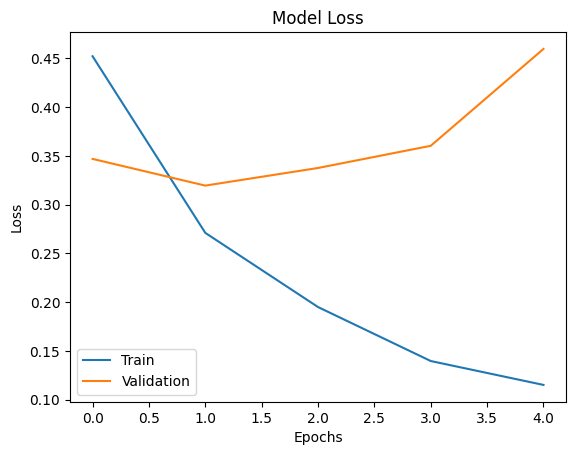

In [8]:
# 8. Plot Graphs
# -----------------------------
# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [9]:
# 9. IMPROVEMENT 1: LSTM with Dropout
# -----------------------------
model_dropout = Sequential()
model_dropout.add(Embedding(vocab_size, 128, input_length=max_len))
model_dropout.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model_dropout.add(Dense(1, activation='sigmoid'))

model_dropout.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\nTraining model with Dropout...")
model_dropout.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)



Training model with Dropout...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 116s 356ms/step - accuracy: 0.7611 - loss: 0.4853 - val_accuracy: 0.8258 - val_loss: 0.4018
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 111s 354ms/step - accuracy: 0.8613 - loss: 0.3359 - val_accuracy: 0.8410 - val_loss: 0.4023
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 112s 357ms/step - accuracy: 0.8227 - loss: 0.3967 - val_accuracy: 0.8244 - val_loss: 0.3997
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 108s 346ms/step - accuracy: 0.8367 - loss: 0.3734 - val_accuracy: 0.7092 - val_loss: 0.5484
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 349ms/step - accuracy: 0.8658 - loss: 0.3165 - val_accuracy: 0.8402 - val_loss: 0.3958


In [10]:
# 10. IMPROVEMENT 2: Stacked LSTM
# -----------------------------
model_stacked = Sequential()
model_stacked.add(Embedding(vocab_size, 128, input_length=max_len))
model_stacked.add(LSTM(64, return_sequences=True))
model_stacked.add(LSTM(32))
model_stacked.add(Dense(1, activation='sigmoid'))

model_stacked.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\nTraining Stacked LSTM model...")
model_stacked.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)


Training Stacked LSTM model...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 118s 364ms/step - accuracy: 0.7688 - loss: 0.4802 - val_accuracy: 0.8530 - val_loss: 0.3615
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 115s 367ms/step - accuracy: 0.8885 - loss: 0.2827 - val_accuracy: 0.8718 - val_loss: 0.3182
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 117s 373ms/step - accuracy: 0.9246 - loss: 0.2019 - val_accuracy: 0.8610 - val_loss: 0.3444
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 114s 365ms/step - accuracy: 0.9442 - loss: 0.1528 - val_accuracy: 0.8714 - val_loss: 0.3644
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 114s 365ms/step - accuracy: 0.9672 - loss: 0.0980 - val_accuracy: 0.8528 - val_loss: 0.4530
